In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


# Load Dataset
# Dataset Breast Cancer: 569 sample, 30 fitur, 2 kelas
data = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Scaling Data
# SVM sensitif terhadap skala fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 1. Perbandingan Kernel Linear vs RBF

models = {
    "SVM Linear": SVC(kernel="linear", C=1),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale")
}

print("=== Perbandingan Kernel Linear vs RBF ===")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print("\n", name)
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, pred, target_names=data.target_names))



=== Perbandingan Kernel Linear vs RBF ===

 SVM Linear
Accuracy: 0.956
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


 SVM RBF
Accuracy: 0.982
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# Load Dataset

data = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)


# Scaling Data

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Tuning Parameter

results = []

kernels = ["linear", "rbf"]
C_values = [0.1, 1.0, 10.0]
gamma_values = [0.01, 0.1, 1]

for kernel in kernels:
    for C in C_values:

        # kernel linear tidak butuh gamma
        if kernel == "linear":
            model = SVC(kernel=kernel, C=C)
            model.fit(X_train, y_train)

            pred = model.predict(X_test)
            acc = accuracy_score(y_test, pred)

            results.append(["Linear", C, "-", round(acc,3)])

        else:
            for gamma in gamma_values:

                model = SVC(kernel=kernel, C=C, gamma=gamma)
                model.fit(X_train, y_train)

                pred = model.predict(X_test)
                acc = accuracy_score(y_test, pred)

                results.append(["RBF", C, gamma, round(acc,3)])


# Membuat Tabel Hasil

df = pd.DataFrame(results, columns=["Kernel", "C", "Gamma", "Accuracy"])

print("\n==============================")
print("HASIL TUNING PARAMETER")
print("==============================")
print(df)

# ====================================================
# Model Terbaik
# ====================================================
best_model = df.loc[df["Accuracy"].idxmax()]

print("\n==============================")
print("MODEL TERBAIK")
print("==============================")
print(best_model)


HASIL TUNING PARAMETER
    Kernel     C Gamma  Accuracy
0   Linear   0.1     -     0.982
1   Linear   1.0     -     0.956
2   Linear  10.0     -     0.965
3      RBF   0.1  0.01     0.965
4      RBF   0.1   0.1     0.947
5      RBF   0.1     1     0.623
6      RBF   1.0  0.01     0.965
7      RBF   1.0   0.1     0.965
8      RBF   1.0     1     0.632
9      RBF  10.0  0.01     0.982
10     RBF  10.0   0.1     0.965
11     RBF  10.0     1     0.632

MODEL TERBAIK
Kernel      Linear
C              0.1
Gamma            -
Accuracy     0.982
Name: 0, dtype: object


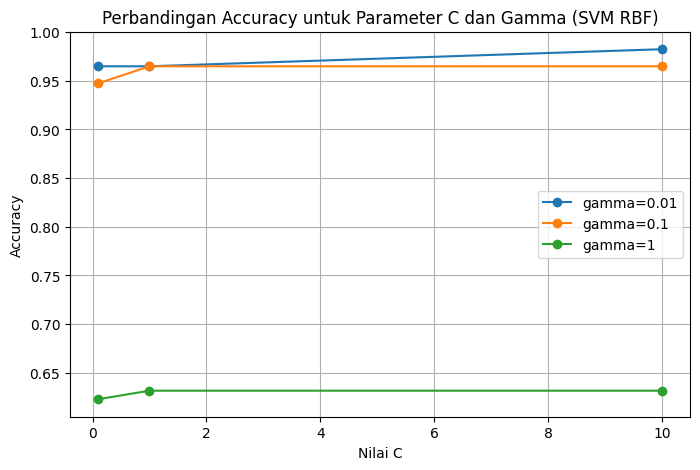

In [11]:
import matplotlib.pyplot as plt

# ===============================================
# Grafik Accuracy
# ===============================================
plt.figure(figsize=(8,5))

for gamma in [0.01, 0.1, 1]:
    subset = df_results[df_results["Gamma"] == gamma]
    plt.plot(subset["C"], subset["Accuracy"], marker='o', label=f"gamma={gamma}")

plt.xlabel("Nilai C")
plt.ylabel("Accuracy")
plt.title("Perbandingan Accuracy untuk Parameter C dan Gamma (SVM RBF)")
plt.legend()
plt.grid(True)

plt.show()